1. Compare DoG, Harris, Shi-Tomasi, and FAST feature detectors for repeatability, speed, and number of features detected. Examine scale, translation, and rotation using camera-captured images. Do not digitally rotate or scale the images.


In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "images_hw2").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "homework_2"))
from utils import FeatureComparison as comparison
from importlib import reload
comparison = reload(comparison)
sequences = comparison.load_sequences(ROOT)


FileNotFoundError: /home/megrad/Documents/GitHub/ME566/images_hw2/images/hw2_translation_images

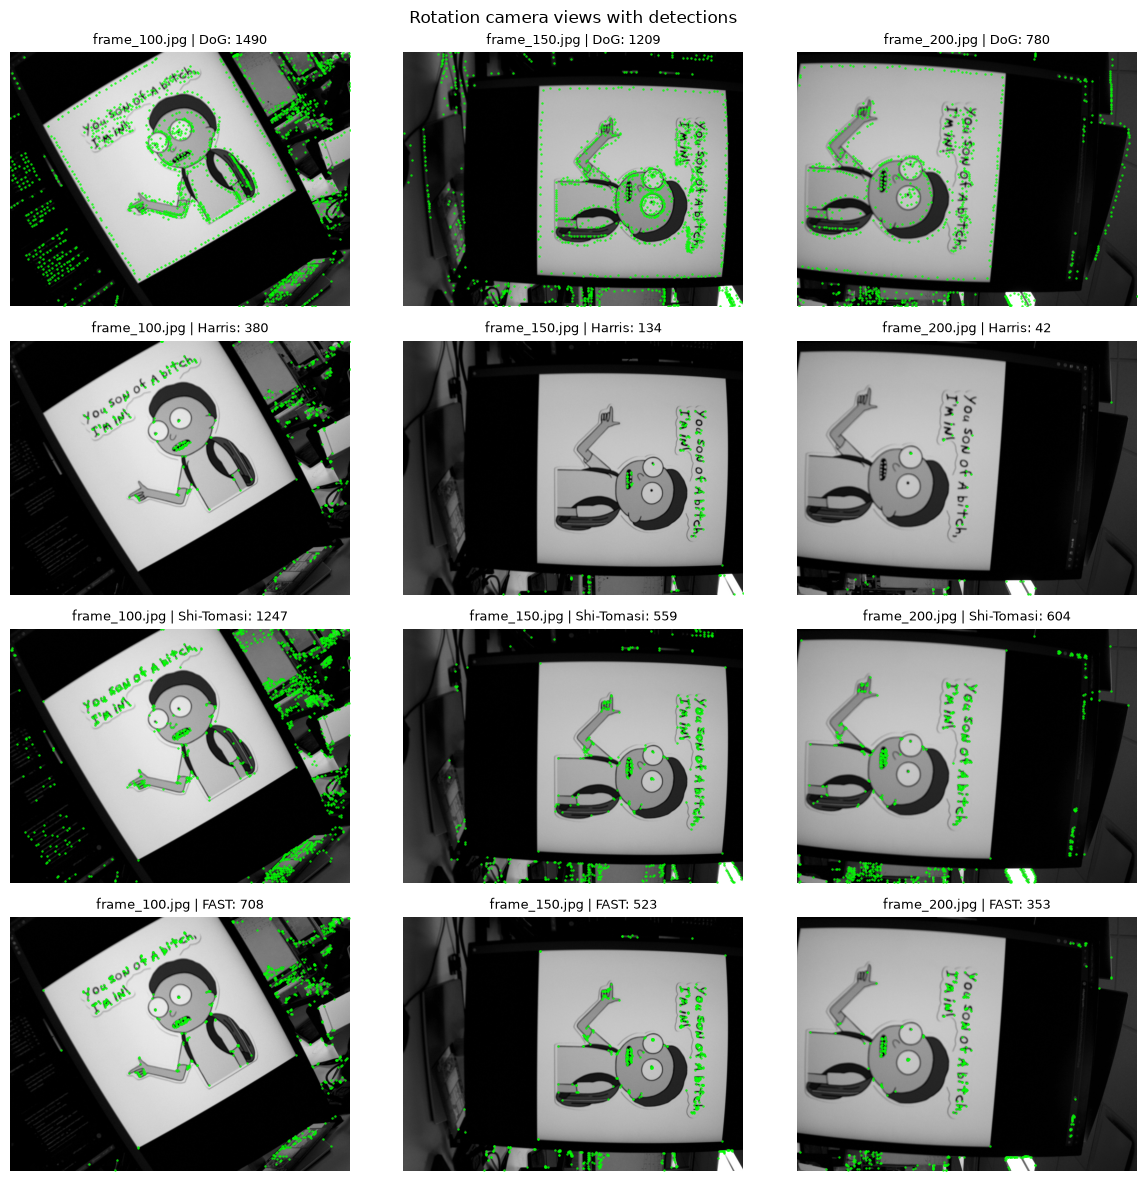

In [ ]:
comparison.show_detector_views(sequences, "rotation")


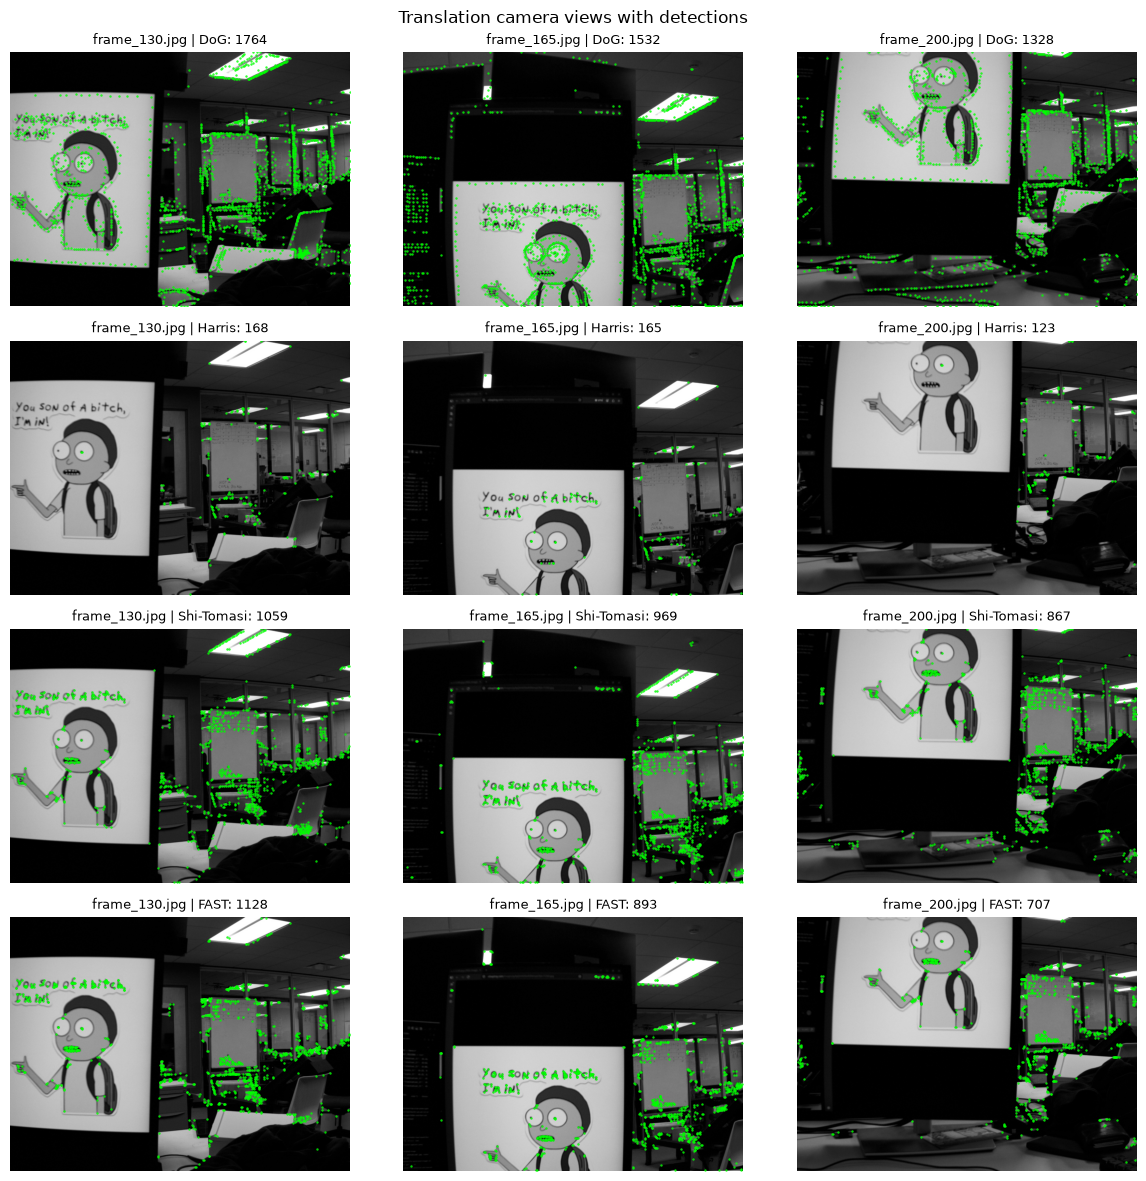

In [ ]:
comparison.show_detector_views(sequences, "translation")


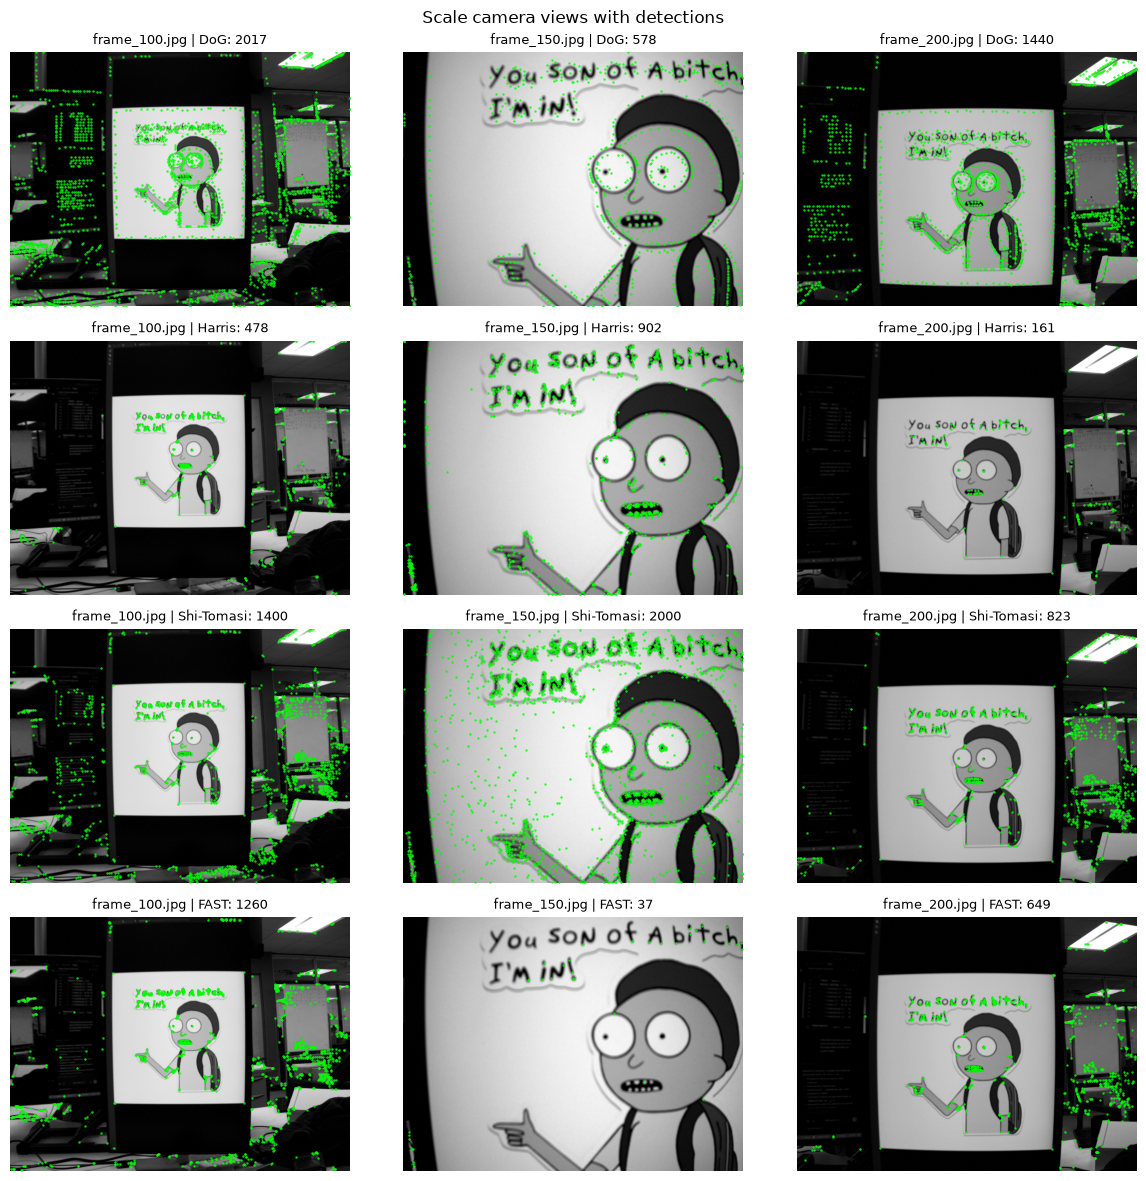

In [ ]:
comparison.show_detector_views(sequences, "scale")


                        features  milliseconds  repeatability
motion      detector                                         
rotation    DoG         1298.667       879.536          0.585
            FAST         591.500         1.794          0.601
            Harris       199.500        31.307          0.412
            Shi-Tomasi   914.833        17.096          0.567
scale       DoG         1232.833       703.239          0.465
            FAST         572.167         1.320          0.444
            Harris       391.833        31.365          0.399
            Shi-Tomasi  1060.000        20.804          0.571
translation DoG         1657.000       803.827          0.471
            FAST        1051.400         2.004          0.522
            Harris       228.200        30.485          0.475
            Shi-Tomasi  1097.000        21.071          0.526


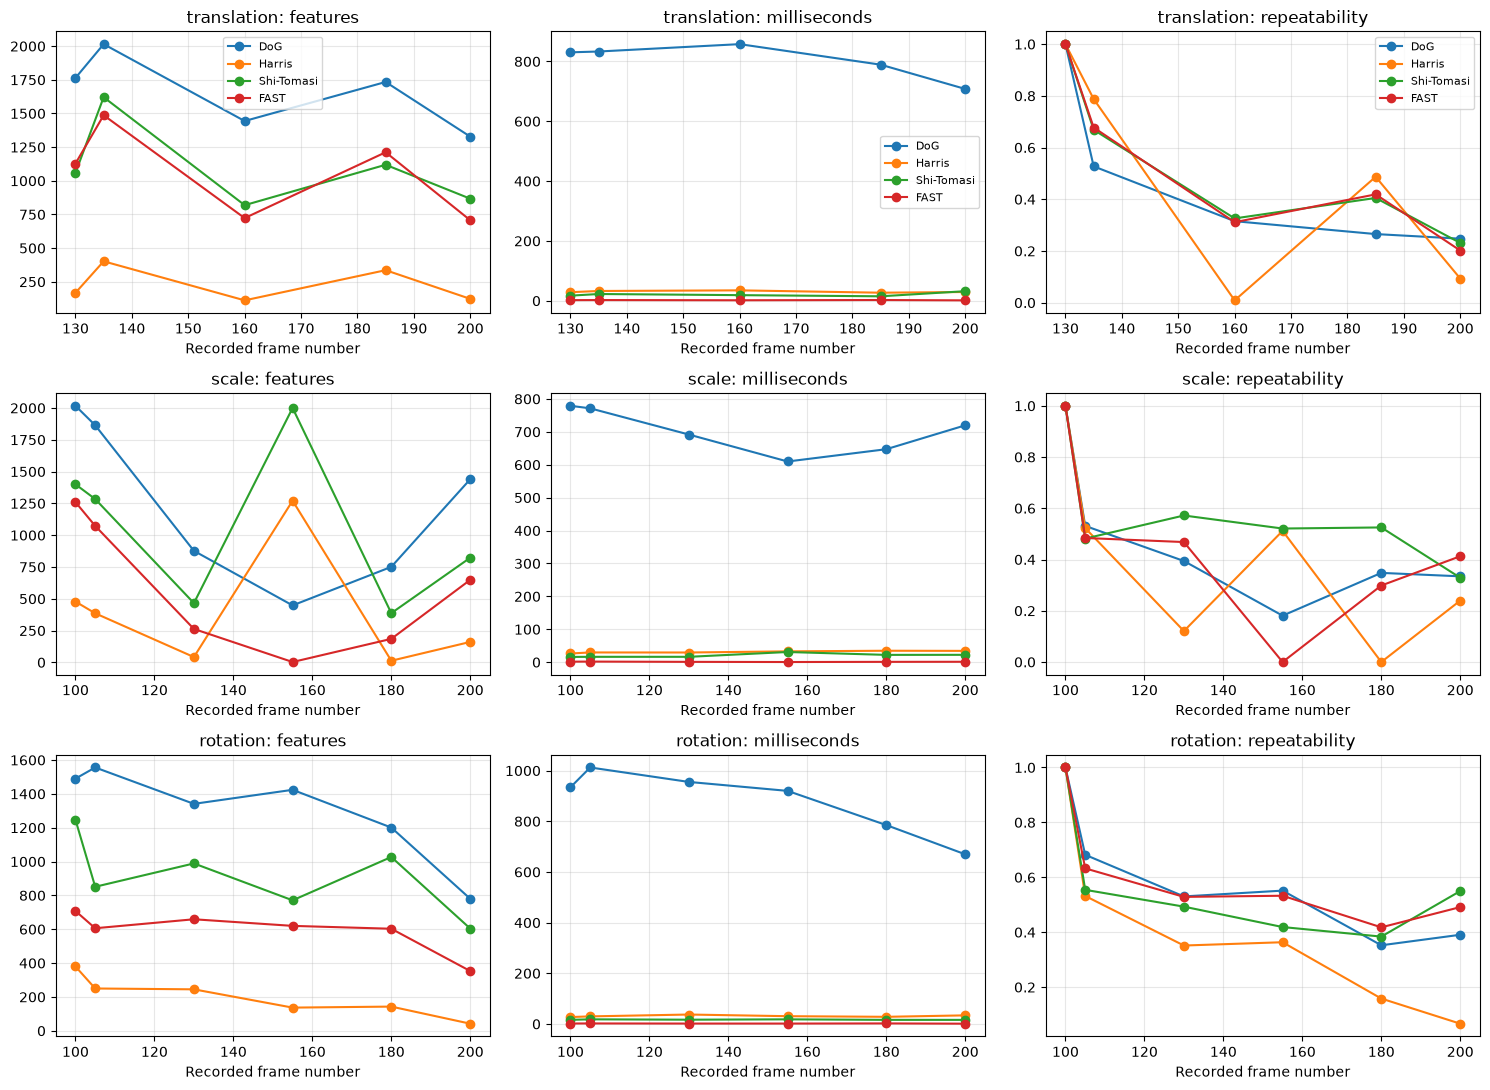

In [ ]:
results = comparison.compare_detectors(sequences)
comparison.show_detector_results(results)


2. Implement a method for selecting a subset of features based on contemporary research. The
method must provide a reasonable set of features covering the whole image. Citations are needed
for this. Octrees and ANMS are candidates for this. I will provide the ANMS paper on
Blackboard. 


In [ ]:
from utils.ANMS import show_anms
selected = show_anms(sequences["translation"][0][1])

3. Conduct feature matching using SIFT, BRIEF, and ORB feature descriptors. Make sure to pick
one type of detections scheme from above to ensure a good comparison. Look at the speed and
quality of matching. Produce a confusion matrix for each one of these. 


In [ ]:
comparison.show_descriptor_visualization(sequences["translation"][0][1])
matches = comparison.compare_descriptors(sequences)
comparison.show_confusion_matrices(matches)
comparison.show_descriptor_summary(matches)
motion, reference, name, target = next(comparison.sampled_pairs(sequences))
comparison.show_match_visualization(reference, target, comparison.homography(reference, target))

4. For the matching method of your choice, construct a ROC curve. Talk about the idea parameters
for your matching technique


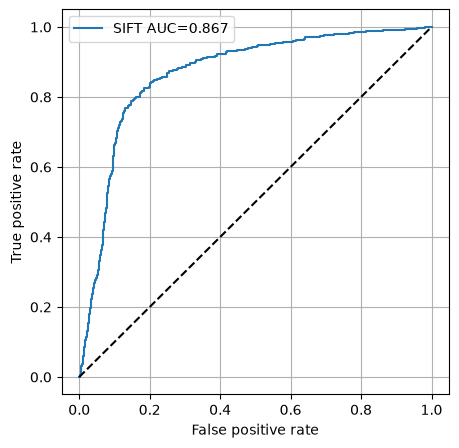

In [ ]:
comparison.show_sift_roc(matches)
